# Figure 1 — Three Sample Types: Loss Trajectories & EWL Progress Signal

Generates **Figure 1** for the EWL paper.

**What it shows:**
- Panel (a): Per-sample cross-entropy loss trajectories over training epochs for three sample categories
- Panel (b): EWL progress signal $s_i$ for the same categories

**Data source:** `outputs/vision/diagnostic/aircraft/ewl_noise20pct/sample_stats/`  
Trained on FGVC-Aircraft with 20% label noise, seed 11.

**Output:** `notebooks/plots/fig1_three_sample_types.pdf` and `.png`

## 1. Imports & paths

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
SAMPLE_STATS_DIR = Path("../outputs/vision/diagnostic/aircraft/ewl_noise20pct/sample_stats")
OUT_DIR          = Path("plots")
OUT_DIR.mkdir(exist_ok=True)

## 2. Load per-sample stats

Each `.npz` file corresponds to one epoch and contains per-sample arrays:
`ids`, `loss`, `prev_ema`, `curr_ema`, `signal`, `weight`, `velocity`.  
`noisy_mask.npy` flags which sample indices received a corrupted label.

In [2]:
noisy_mask = np.load(SAMPLE_STATS_DIR / "noisy_mask.npy")
epochs     = list(range(2, 11))   # epoch 1 has no EMA history yet

data = {}
for ep in epochs:
    d = np.load(SAMPLE_STATS_DIR / f"sample_stats_ep{ep:02d}.npz")
    for i, sid in enumerate(d["ids"]):
        if sid not in data:
            data[sid] = {
                "loss":   {},
                "signal": {},
                "noisy":  bool(noisy_mask[int(sid) - 1]) if int(sid) - 1 < len(noisy_mask) else False,
            }
        data[sid]["loss"][ep]   = float(d["loss"][i])
        data[sid]["signal"][ep] = float(d["signal"][i])

# Keep only samples that appear in every epoch
full    = [sid for sid, v in data.items() if len(v["loss"]) == len(epochs)]
clean_f = [sid for sid in full if not data[sid]["noisy"]]
noisy_f = [sid for sid in full if     data[sid]["noisy"]]

print(f"Full-coverage samples: {len(full)}  "
      f"(clean={len(clean_f)}, noisy={len(noisy_f)})")

Full-coverage samples: 326  (clean=266, noisy=60)


## 3. Classify samples into three categories

| Category | Criterion |
|---|---|
| **Learned** | Clean sample, final loss < 0.15, starting loss > 2.5 |
| **Frontier** | Clean sample, final loss 0.3–1.5, starting loss > 2.5, ≥5 monotone decreasing steps |
| **Conflicting** | Noisy sample, mean loss > 4.5, final loss > 3.5 |

In [3]:
def get_loss(sid):   return np.array([data[sid]["loss"][ep]   for ep in epochs])
def get_signal(sid): return np.array([data[sid]["signal"][ep] for ep in epochs])
def monotone(ls):    return sum(ls[i] > ls[i + 1] for i in range(len(ls) - 1))

mastered_pool = [
    sid for sid in clean_f
    if get_loss(sid)[-1] < 0.15 and get_loss(sid)[0] > 2.5
]
frontier_pool = [
    sid for sid in clean_f
    if 0.3 < get_loss(sid)[-1] < 1.5
    and get_loss(sid)[0] > 2.5
    and monotone(get_loss(sid)) >= 5
]
conflict_pool = [
    sid for sid in noisy_f
    if np.mean(get_loss(sid)) > 4.5 and get_loss(sid)[-1] > 3.5
]

print(f"Learned   n={len(mastered_pool)}")
print(f"Frontier   n={len(frontier_pool)}")
print(f"Conflicting n={len(conflict_pool)}")

Learned   n=84
Frontier   n=23
Conflicting n=9


## 4. Compute mean ± std per category

In [4]:
def pool_stats(pool, fn):
    mat = np.vstack([fn(s) for s in pool])
    return mat.mean(0), mat.std(0)

# Loss stats
m_mean, m_std = pool_stats(mastered_pool, get_loss)
f_mean, f_std = pool_stats(frontier_pool, get_loss)
c_mean, c_std = pool_stats(conflict_pool, get_loss)

# Signal stats
ms_mean, ms_std = pool_stats(mastered_pool, get_signal)
fs_mean, fs_std = pool_stats(frontier_pool, get_signal)
cs_mean, cs_std = pool_stats(conflict_pool, get_signal)

# Light smoothing on loss means for cleaner lines
m_mean = gaussian_filter1d(m_mean, sigma=0.7)
f_mean = gaussian_filter1d(f_mean, sigma=0.7)
c_mean = gaussian_filter1d(c_mean, sigma=0.7)

## 5. Plot

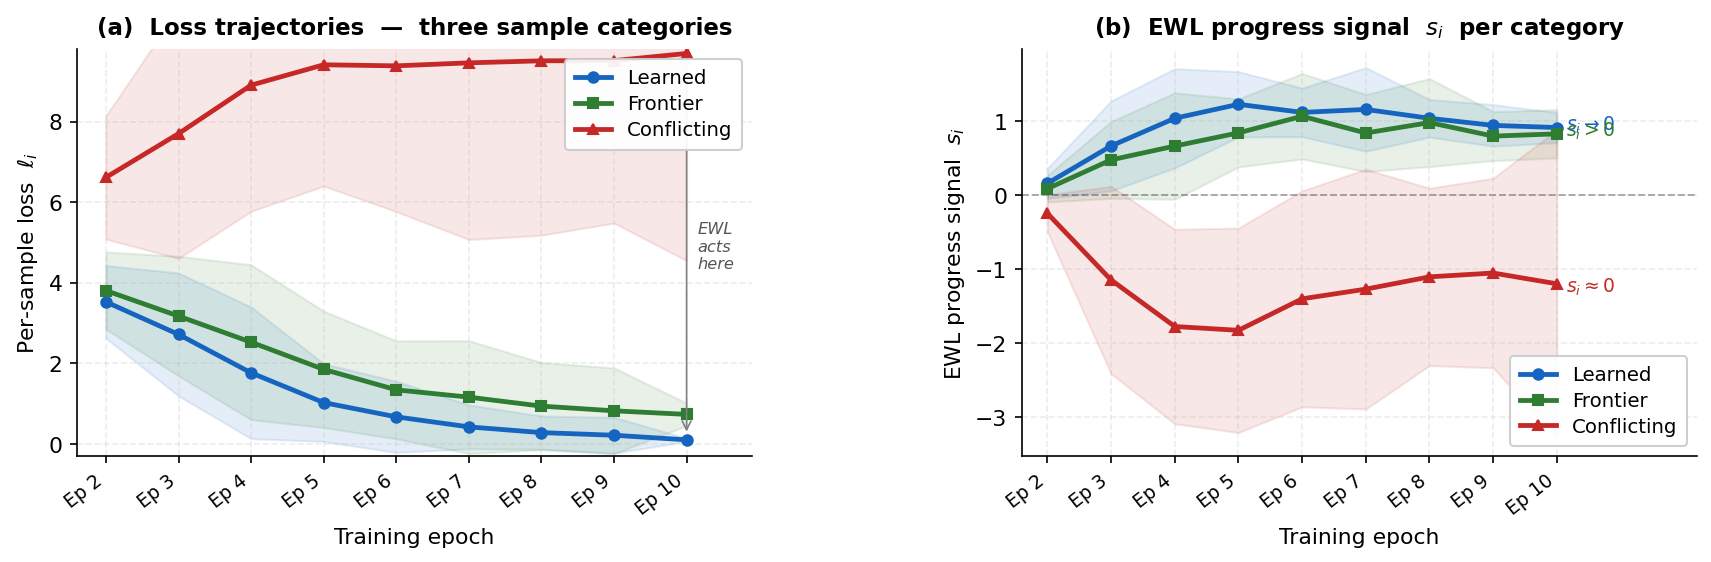

Saved → plots/fig1_three_sample_types.pdf  &  .png


In [ ]:
x         = np.arange(len(epochs))
ep_labels = [f"Ep {e}" for e in epochs]

# Colours
C_m, C_f, C_c = "#1565C0", "#2E7D32", "#C62828"   # blue, green, red

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         10.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelsize":    10.5,
    "axes.titlesize":    11.5,
    "legend.fontsize":   9.5,
    "figure.dpi":        150,
    "axes.grid":         True,
    "grid.alpha":        0.22,
    "grid.linestyle":    "--",
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6),
                                gridspec_kw={"wspace": 0.40})
fig.subplots_adjust(left=0.07, right=0.97, top=0.87, bottom=0.28)

# ── Panel A: Loss trajectories ────────────────────────────────────────────────
for mean, std, c in [(m_mean, m_std, C_m), (f_mean, f_std, C_f), (c_mean, c_std, C_c)]:
    ax1.fill_between(x, mean - std, mean + std, color=c, alpha=0.11)

# ax1.plot(x, m_mean, color=C_m, lw=2.3, marker="o", ms=5,
#          label="Learned  (clean, early convergence)")
# ax1.plot(x, f_mean, color=C_f, lw=2.3, marker="s", ms=5,
#          label="Frontier  (clean, actively declining)")
# ax1.plot(x, c_mean, color=C_c, lw=2.3, marker="^", ms=5,
#          label="Conflicting  (noisy, stagnant / high)")

ax1.plot(x, m_mean, color=C_m, lw=2.3, marker="o", ms=5,
         label="Learned")
ax1.plot(x, f_mean, color=C_f, lw=2.3, marker="s", ms=5,
         label="Frontier")
ax1.plot(x, c_mean, color=C_c, lw=2.3, marker="^", ms=5,
         label="Conflicting")

# Double-headed arrow showing the gap EWL exploits
ax1.annotate("", xy=(x[-1], m_mean[-1] + 0.1), xytext=(x[-1], c_mean[-1] - 0.3),
             arrowprops=dict(arrowstyle="<->", color="grey", lw=0.8))
ax1.text(x[-1] + 0.15, (m_mean[-1] + c_mean[-1]) / 2, "EWL\nacts\nhere",
         fontsize=7.8, color="#555", va="center", ha="left", style="italic")

ax1.set_xticks(x)
ax1.set_xticklabels(ep_labels, rotation=38, ha="right", fontsize=9)
ax1.set_ylabel("Per-sample loss  $\\ell_i$", fontsize=10.5)
ax1.set_xlabel("Training epoch", fontsize=10.5)
ax1.set_title("(a)  Loss trajectories  —  three sample categories",
              fontsize=11,  pad=7)
ax1.set_ylim(-0.3, 9.8)
ax1.set_xlim(-0.4, 8.9)
ax1.legend(loc="upper right", framealpha=0.93, handlelength=1.8,
           borderpad=0.5, labelspacing=0.35)

# ── Panel B: EWL progress signal ─────────────────────────────────────────────
for mean, std, c in [(ms_mean, ms_std, C_m), (fs_mean, fs_std, C_f), (cs_mean, cs_std, C_c)]:
    ax2.fill_between(x, mean - std, mean + std, color=c, alpha=0.11)

ax2.axhline(0, color="black", lw=0.9, ls="--", alpha=0.35, zorder=1)
ax2.plot(x, ms_mean, color=C_m, lw=2.3, marker="o", ms=5, label="Learned")
ax2.plot(x, fs_mean, color=C_f, lw=2.3, marker="s", ms=5, label="Frontier")
ax2.plot(x, cs_mean, color=C_c, lw=2.3, marker="^", ms=5, label="Conflicting")

# Inline end-of-line labels
def end_label(ax, x_end, y_end, txt, c, dy=0):
    ax.text(x_end + 0.15, y_end + dy, txt, color=c, fontsize=9,
            va="center", ha="left", fontweight="bold")

end_label(ax2, x[-1], ms_mean[-1], "$s_i \\to 0$",     C_m,  0.04)
end_label(ax2, x[-1], fs_mean[-1], "$s_i > 0$",        C_f,  0.04)
end_label(ax2, x[-1], cs_mean[-1], "$s_i \\approx 0$", C_c, -0.04)

ax2.set_xticks(x)
ax2.set_xticklabels(ep_labels, rotation=38, ha="right", fontsize=9)
ax2.set_ylabel("EWL progress signal  $s_i$", fontsize=10.5)
ax2.set_xlabel("Training epoch", fontsize=10.5)
ax2.set_title("(b)  EWL progress signal  $s_i$  per category",
              fontsize=11,  pad=7)
ax2.set_xlim(-0.4, 10.2)
ax2.legend(loc="lower right", framealpha=0.93, handlelength=1.8,
           borderpad=0.5, labelspacing=0.35)

# ── Caption ───────────────────────────────────────────────────────────────────
n_m, n_f, n_c = len(mastered_pool), len(frontier_pool), len(conflict_pool)
# fig.text(
#     0.5, 0.01,
#     f"Figure 1.  Per-sample loss (a) and EWL progress signal $s_i$ (b) for three sample categories "
#     f"on FGVC-Aircraft (20% label noise).  Shaded bands = ±1 std across category members.\n"
#     f"Blue circles (Learned, $n$={n_m}): clean samples that converge early — "
#     f"$s_i \\to 0$ suppresses their gradient once learned.  "
#     f"Green squares (Frontier, $n$={n_f}): clean samples with actively declining loss — "
#     f"sustained positive $s_i$ earns them higher EWL weight throughout training.\n"
#     f"Red triangles (Conflicting, $n$={n_c}): noisy/corrupted samples that stagnate at high loss — "
#     f"$s_i \\approx 0$ automatically down-weights them with no explicit noise model.",
#     ha="center", va="bottom", fontsize=8.2, color="#333333", linespacing=1.55,
# )

plt.savefig(OUT_DIR / "fig1_three_sample_types.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → plots/fig1_three_sample_types.pdf  &  .png")

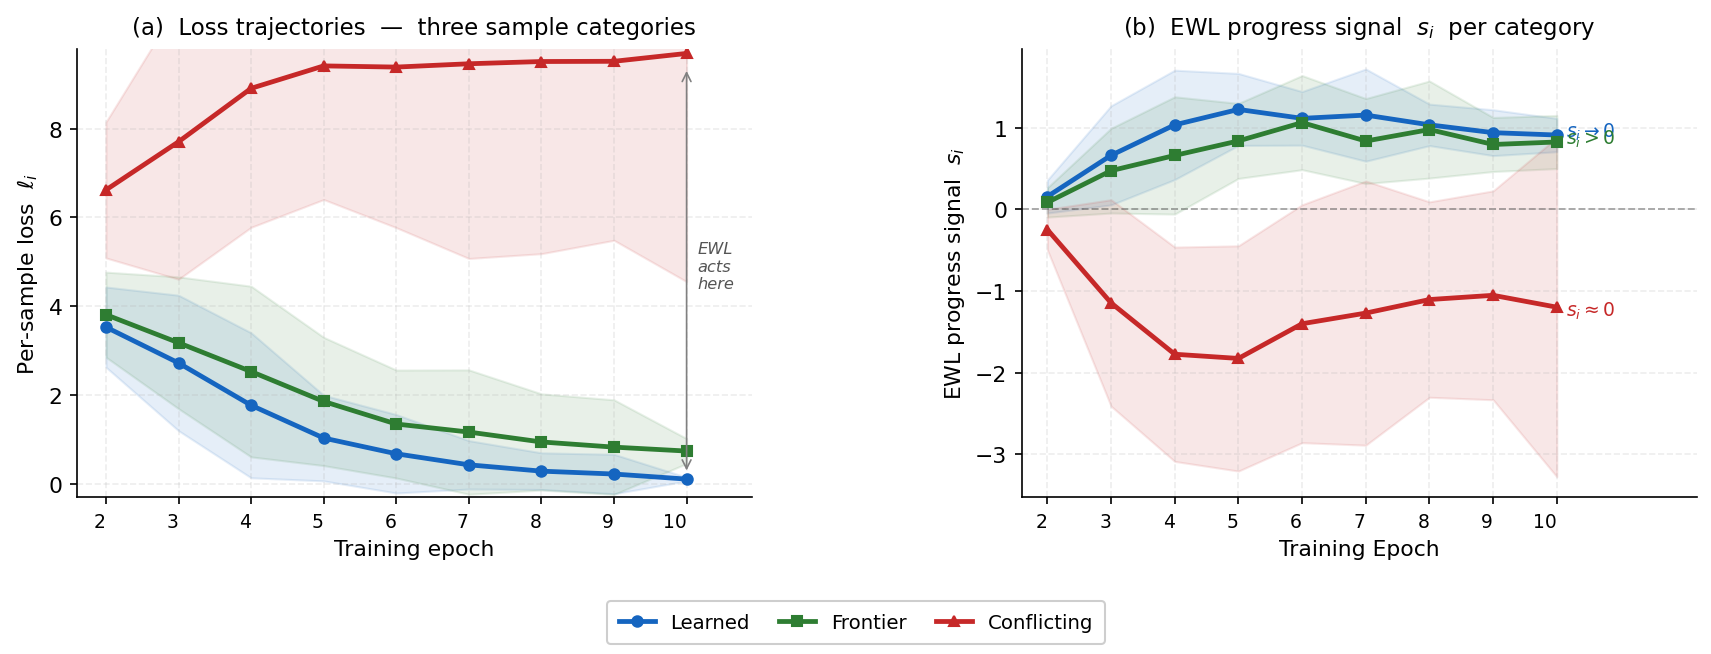

Saved → plots/fig1_three_sample_types.pdf


In [7]:
x         = np.arange(len(epochs))
ep_labels = [str(e) for e in epochs]

# Colours
C_m, C_f, C_c = "#1565C0", "#2E7D32", "#C62828"   # blue, green, red

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         10.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelsize":    10.5,
    "axes.titlesize":    11.5,
    "legend.fontsize":   9.5,
    "figure.dpi":        150,
    "axes.grid":         True,
    "grid.alpha":        0.22,
    "grid.linestyle":    "--",
})

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.6),
    gridspec_kw={"wspace": 0.40}
)

# Adjust margins (extra bottom space for shared legend)
fig.subplots_adjust(left=0.07, right=0.97, top=0.87, bottom=0.22)

# ── Panel A: Loss trajectories ────────────────────────────────────────────────
for mean, std, c in [
    (m_mean, m_std, C_m),
    (f_mean, f_std, C_f),
    (c_mean, c_std, C_c)
]:
    ax1.fill_between(x, mean - std, mean + std, color=c, alpha=0.11)

ax1.plot(x, m_mean, color=C_m, lw=2.3, marker="o", ms=5, label="Learned")
ax1.plot(x, f_mean, color=C_f, lw=2.3, marker="s", ms=5, label="Frontier")
ax1.plot(x, c_mean, color=C_c, lw=2.3, marker="^", ms=5, label="Conflicting")

# Double-headed arrow
ax1.annotate(
    "", 
    xy=(x[-1], m_mean[-1] + 0.1),
    xytext=(x[-1], c_mean[-1] - 0.3),
    arrowprops=dict(arrowstyle="<->", color="grey", lw=0.8)
)

ax1.text(
    x[-1] + 0.15,
    (m_mean[-1] + c_mean[-1]) / 2,
    "EWL\nacts\nhere",
    fontsize=7.8,
    color="#555",
    va="center",
    ha="left",
    style="italic"
)

ax1.set_xticks(x)
ax1.set_xticklabels(ep_labels, ha="right", fontsize=9)
ax1.set_ylabel("Per-sample loss  $\\ell_i$", fontsize=10.5)
ax1.set_xlabel("Training epoch", fontsize=10.5)
ax1.set_title(
    "(a)  Loss trajectories  —  three sample categories",
    fontsize=11,
    
    pad=7
)
ax1.set_ylim(-0.3, 9.8)
ax1.set_xlim(-0.4, 8.9)

# ── Panel B: EWL progress signal ─────────────────────────────────────────────
for mean, std, c in [
    (ms_mean, ms_std, C_m),
    (fs_mean, fs_std, C_f),
    (cs_mean, cs_std, C_c)
]:
    ax2.fill_between(x, mean - std, mean + std, color=c, alpha=0.11)

ax2.axhline(0, color="black", lw=0.9, ls="--", alpha=0.35, zorder=1)

ax2.plot(x, ms_mean, color=C_m, lw=2.3, marker="o", ms=5, label="Learned")
ax2.plot(x, fs_mean, color=C_f, lw=2.3, marker="s", ms=5, label="Frontier")
ax2.plot(x, cs_mean, color=C_c, lw=2.3, marker="^", ms=5, label="Conflicting")

# Inline labels
def end_label(ax, x_end, y_end, txt, c, dy=0):
    ax.text(
        x_end + 0.15,
        y_end + dy,
        txt,
        color=c,
        fontsize=9,
        va="center",
        ha="left",
        fontweight="bold"
    )

end_label(ax2, x[-1], ms_mean[-1], "$s_i \\to 0$",     C_m,  0.04)
end_label(ax2, x[-1], fs_mean[-1], "$s_i > 0$",        C_f,  0.04)
end_label(ax2, x[-1], cs_mean[-1], "$s_i \\approx 0$", C_c, -0.04)

ax2.set_xticks(x)
ax2.set_xticklabels(ep_labels, ha="right", fontsize=9)
ax2.set_ylabel("EWL progress signal  $s_i$", fontsize=10.5)
ax2.set_xlabel("Training Epoch", fontsize=10.5)
ax2.set_title(
    "(b)  EWL progress signal  $s_i$  per category",
    fontsize=11,
    
    pad=7
)
ax2.set_xlim(-0.4, 10.2)

# ── Shared Legend ─────────────────────────────────────────────────────────────
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    frameon=True,
    framealpha=0.95,
    borderpad=0.6,
    columnspacing=1.5,
    handlelength=1.8
)

# ── Save ─────────────────────────────────────────────────────────────────────
plt.savefig(OUT_DIR / "fig1_three_sample_types.pdf", bbox_inches="tight", dpi=300)
plt.show()

print("Saved → plots/fig1_three_sample_types.pdf")